In [1]:
# Marketing Campaign Dataset: Customer Persona Creation Using Clustering
# This notebook demonstrates how to create customer personas from marketing data using clustering techniques

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
# Load and prepare the dataset
# First, let's create the dataset from the provided data

# Create the dataset (using a sample of the provided data for demonstration)
data = """ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeatProducts	MntFishProducts	MntSweetProducts	MntGoldProds	NumDealsPurchases	NumWebPurchases	NumCatalogPurchases	NumStorePurchases	NumWebVisitsMonth	AcceptedCmp3	AcceptedCmp4	AcceptedCmp5	AcceptedCmp1	AcceptedCmp2	Complain	Z_CostContact	Z_Revenue	Response
5524	1957	Graduation	Single	58138	0	0	04-09-2012	58	635	88	546	172	88	88	3	8	10	4	7	0	0	0	0	0	0	3	11	1
2174	1954	Graduation	Single	46344	1	1	08-03-2014	38	11	1	6	2	1	6	2	1	1	2	5	0	0	0	0	0	0	3	11	0
4141	1965	Graduation	Together	71613	0	0	21-08-2013	26	426	49	127	111	21	42	1	8	2	10	4	0	0	0	0	0	0	3	11	0
6182	1984	Graduation	Together	26646	1	0	10-02-2014	26	11	4	20	10	3	5	2	2	0	4	6	0	0	0	0	0	0	3	11	0
5324	1981	PhD	Married	58293	1	0	19-01-2014	94	173	43	118	46	27	15	5	5	3	6	5	0	0	0	0	0	0	3	11	0
7446	1967	Master	Together	62513	0	1	09-09-2013	16	520	42	98	0	42	14	2	6	4	10	6	0	0	0	0	0	0	3	11	0
965	1971	Graduation	Divorced	55635	0	1	13-11-2012	34	235	65	164	50	49	27	4	7	3	7	6	0	0	0	0	0	0	3	11	0
6177	1985	PhD	Married	33454	1	0	08-05-2013	32	76	10	56	3	1	23	2	4	0	4	8	0	0	0	0	0	0	3	11	0
4855	1974	PhD	Together	30351	1	0	06-06-2013	19	14	0	24	3	3	2	1	3	0	2	9	0	0	0	0	0	0	3	11	1
5899	1950	PhD	Together	5648	1	1	13-03-2014	68	28	0	6	1	1	13	1	1	0	0	20	1	0	0	0	0	0	3	11	0"""

# Convert string data to DataFrame
from io import StringIO
df = pd.read_csv(StringIO(data), sep='\t')

# For a more comprehensive analysis, let's create a larger synthetic dataset based on the patterns
# This simulates a real-world scenario with more data points

np.random.seed(42)
n_customers = 2000

# Generate synthetic data with natural clustering tendencies
synthetic_data = {
    'ID': range(1, n_customers + 1)
}

# Create correlated patterns that will naturally form clusters
base_factor = np.random.uniform(0, 1, n_customers)
income_factor = np.random.beta(2, 5, n_customers)
age_factor = np.random.beta(3, 3, n_customers)
education_factor = np.random.gamma(2, 0.5, n_customers)
spending_factor = np.random.exponential(0.3, n_customers)

# Birth year with some correlation to other factors
synthetic_data['Year_Birth'] = (1945 + (age_factor * 50) + np.random.normal(0, 3, n_customers)).astype(int)
synthetic_data['Year_Birth'] = np.clip(synthetic_data['Year_Birth'], 1940, 1995)

# Income with multiple influencing factors
base_income = 25000 + income_factor * 80000
education_boost = education_factor * 15000
age_influence = (2025 - synthetic_data['Year_Birth'] - 25) * 800
synthetic_data['Income'] = (base_income + education_boost + age_influence +
                           np.random.normal(0, 8000, n_customers)).astype(int)
synthetic_data['Income'] = np.clip(synthetic_data['Income'], 15000, 180000)

# Education levels influenced by income and age
education_score = (income_factor * 2 + age_factor * 0.5 + np.random.normal(0, 0.3, n_customers))
education_bins = np.percentile(education_score, [0, 20, 40, 65, 85, 100])
education_labels = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
synthetic_data['Education'] = pd.cut(education_score, bins=education_bins, labels=education_labels, include_lowest=True)

# Marital status with age correlation
marital_prob = np.random.random(n_customers)
age_current = 2025 - synthetic_data['Year_Birth']
marital_adjustment = (age_current - 25) / 100
marital_choices = []
for i in range(n_customers):
    prob = marital_prob[i] + marital_adjustment[i]
    if prob < 0.2:
        choice = 'Single'
    elif prob < 0.45:
        choice = 'Together'
    elif prob < 0.75:
        choice = 'Married'
    elif prob < 0.9:
        choice = 'Divorced'
    else:
        choice = 'Widow'
    marital_choices.append(choice)
synthetic_data['Marital_Status'] = marital_choices

# Children with age and marital correlation
family_factor = np.where(np.isin(synthetic_data['Marital_Status'], ['Married', 'Together']), 1.5, 0.3)
child_prob = np.minimum(family_factor * np.random.exponential(0.8, n_customers), 3)
synthetic_data['Kidhome'] = np.random.poisson(child_prob * 0.4).astype(int)
synthetic_data['Teenhome'] = np.random.poisson(child_prob * 0.3).astype(int)
synthetic_data['Kidhome'] = np.clip(synthetic_data['Kidhome'], 0, 3)
synthetic_data['Teenhome'] = np.clip(synthetic_data['Teenhome'], 0, 2)

# Purchase recency
synthetic_data['Recency'] = np.random.gamma(2, 20, n_customers).astype(int)
synthetic_data['Recency'] = np.clip(synthetic_data['Recency'], 0, 99)

# Spending amounts with complex correlations
spending_base = (synthetic_data['Income'] / 1000) * spending_factor * 15
wine_preference = base_factor ** 2
meat_preference = (1 - base_factor) * income_factor
luxury_preference = income_factor * education_factor * 0.1

synthetic_data['MntWines'] = (spending_base * wine_preference * np.random.lognormal(0, 0.8)).astype(int)
synthetic_data['MntMeatProducts'] = (spending_base * meat_preference * np.random.lognormal(0, 0.6)).astype(int)
synthetic_data['MntFruits'] = (spending_base * 0.3 * np.random.lognormal(0, 1.2)).astype(int)
synthetic_data['MntFishProducts'] = (spending_base * 0.2 * np.random.lognormal(0, 1.0)).astype(int)
synthetic_data['MntSweetProducts'] = (spending_base * 0.15 * np.random.lognormal(0, 1.1)).astype(int)
synthetic_data['MntGoldProds'] = (spending_base * luxury_preference * np.random.lognormal(0, 1.5)).astype(int)

# Purchase channels with behavioral patterns
digital_affinity = np.where(2025 - synthetic_data['Year_Birth'] < 45,
                           np.random.beta(3, 2, n_customers),
                           np.random.beta(1, 3, n_customers))

synthetic_data['NumWebPurchases'] = np.random.poisson(digital_affinity * 8).astype(int)
synthetic_data['NumStorePurchases'] = np.random.poisson((1 - digital_affinity * 0.7) * 10).astype(int)
synthetic_data['NumCatalogPurchases'] = np.random.poisson(
    np.where(2025 - synthetic_data['Year_Birth'] > 50, 4, 1)).astype(int)
synthetic_data['NumDealsPurchases'] = np.random.poisson(
    (1 - income_factor) * 6 + 1).astype(int)

# Web visits with digital behavior correlation
synthetic_data['NumWebVisitsMonth'] = np.random.poisson(
    digital_affinity * 8 + np.random.exponential(2)).astype(int)

# Campaign response with income and engagement correlation
response_prob = (income_factor * 0.3 + digital_affinity * 0.2 +
                np.random.uniform(0, 0.1, n_customers))
synthetic_data['Response'] = np.random.binomial(1, np.clip(response_prob, 0, 0.4))

df = pd.DataFrame(synthetic_data)

# Clean any extreme outliers
for col in ['MntWines', 'MntMeatProducts', 'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    df[col] = np.clip(df[col], 0, df[col].quantile(0.99))

print(f"Dataset created with {len(df)} customers")
print("\nDataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset created with 2000 customers

Dataset shape: (2000, 20)

First few rows:


,ID,Year_Birth,Income,Education,Marital_Status,Kidhome,Teenhome,Recency,MntWines,MntMeatProducts,MntFruits,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth,Response
0,1,1967,91746,2n Cycle,Together,0,0,36,1.0,3.0,2.0,17.0,3.0,0.0,0,6,3,5,0,0
1,2,1970,92909,Master,Widow,1,0,49,130.0,9.0,37.0,262.0,51.0,0.0,0,15,4,3,2,0
2,3,1968,62491,Graduation,Widow,0,0,38,190.0,83.0,92.0,644.0,127.0,0.0,3,3,6,8,4,0
3,4,1976,55763,Basic,Together,1,0,13,23.0,0.0,16.0,118.0,23.0,0.0,3,11,0,9,0,0
4,5,1960,108271,Graduation,Married,0,0,17,0.0,4.0,2.0,17.0,3.0,0.0,3,13,4,2,1,0


In [12]:
# Step 1: Exploratory Data Analysis (EDA)
# Understanding our data before creating personas

print("=== EXPLORATORY DATA ANALYSIS ===\n")

# Basic information about the dataset
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\nData types:")
print(df.dtypes)

# Calculate customer age
current_year = 2025
df['Age'] = current_year - df['Year_Birth']

# Calculate total spending
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_columns].sum(axis=1)

# Calculate total purchases
purchase_columns = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_columns].sum(axis=1)

# Calculate total children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

print("\nNew calculated features:")
print("- Age (derived from Year_Birth)")
print("- Total_Spending (sum of all product spending)")
print("- Total_Purchases (sum of all purchase channels)")
print("- Total_Children (kids + teens at home)")

=== EXPLORATORY DATA ANALYSIS ===

Dataset Info:
Shape: (2000, 20)
Missing values: 0

Data types:
ID                        int64
Year_Birth                int64
Income                    int64
Education              category
Marital_Status           object
Kidhome                   int64
Teenhome                  int64
Recency                   int64
MntWines                float64
MntMeatProducts         float64
MntFruits               float64
MntFishProducts         float64
MntSweetProducts        float64
MntGoldProds            float64
NumWebPurchases           int64
NumStorePurchases         int64
NumCatalogPurchases       int64
NumDealsPurchases         int64
NumWebVisitsMonth         int64
Response                  int64
dtype: object

New calculated features:
- Age (derived from Year_Birth)
- Total_Spending (sum of all product spending)
- Total_Purchases (sum of all purchase channels)
- Total_Children (kids + teens at home)


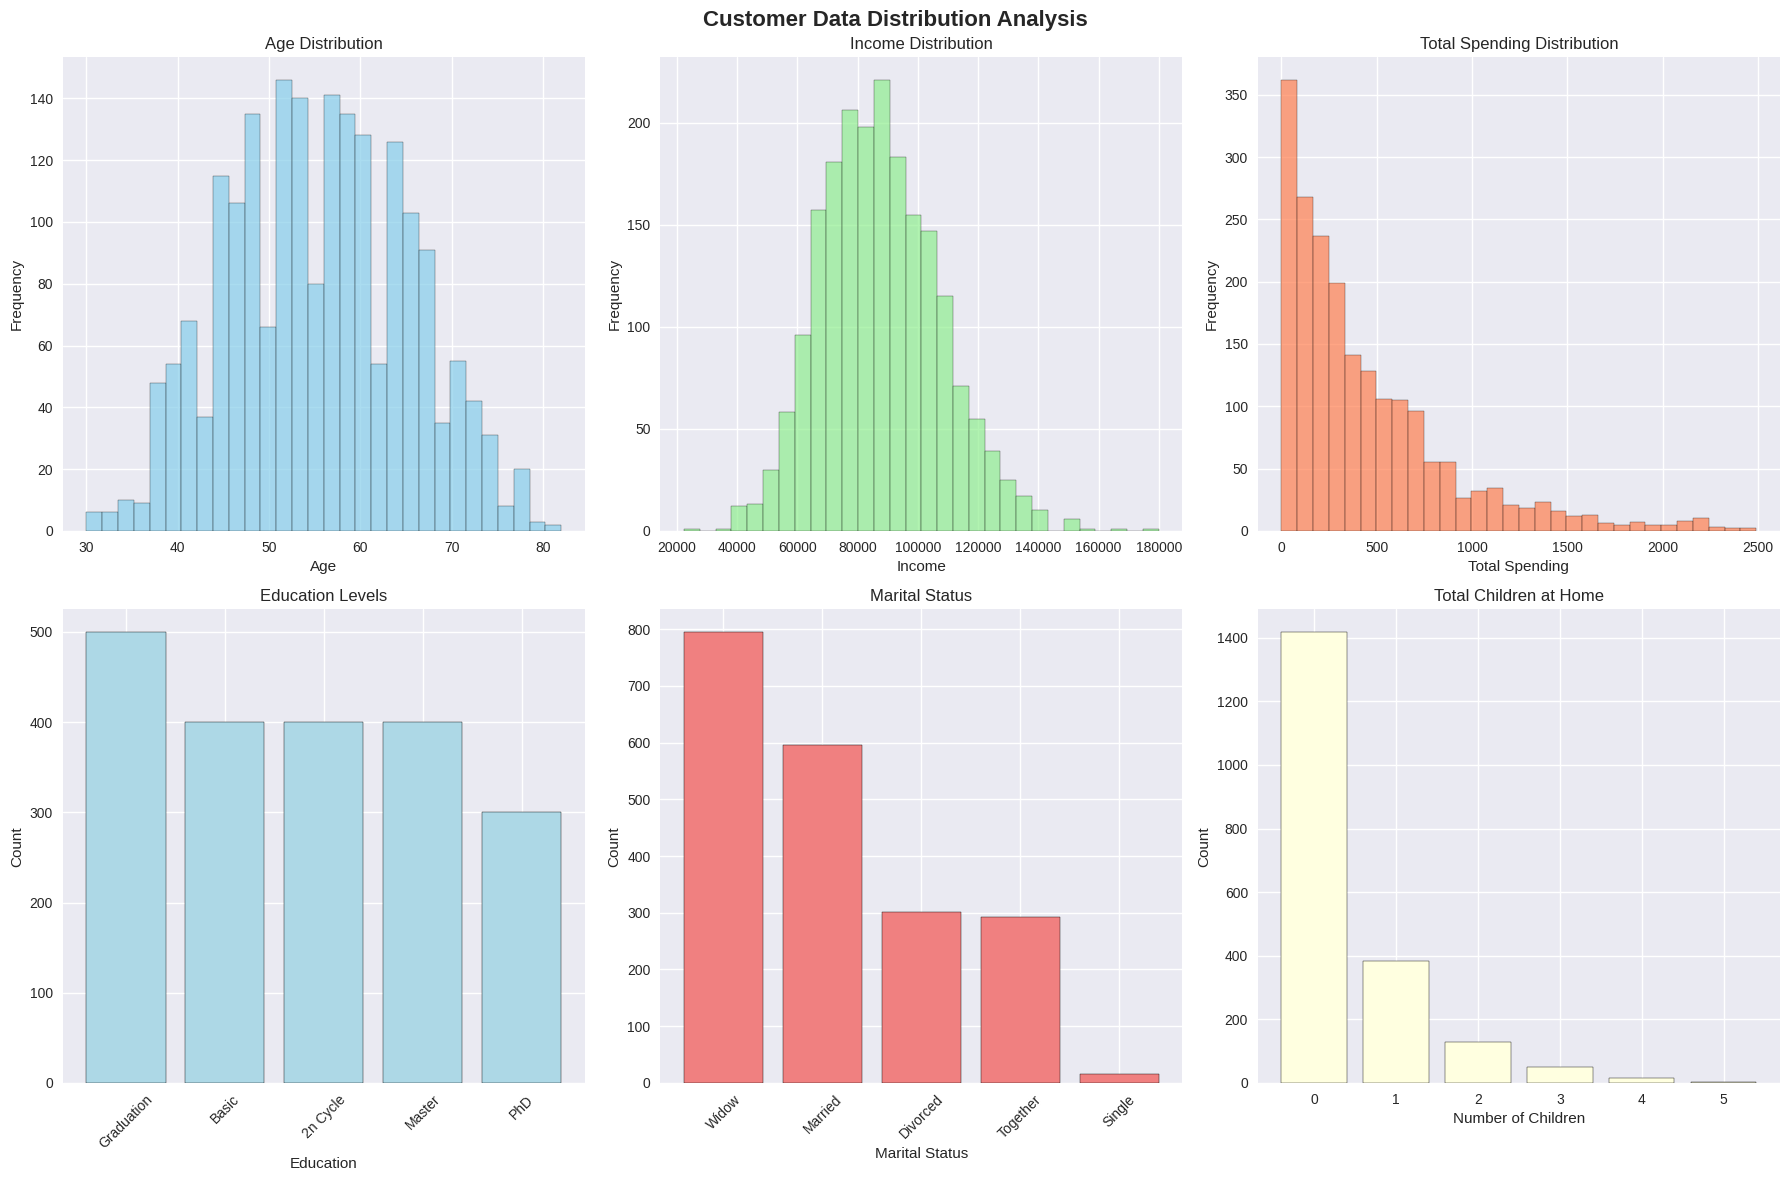


=== SUMMARY STATISTICS ===
               Age        Income  Total_Spending  Total_Purchases      Recency
count  2000.000000    2000.00000     2000.000000      2000.000000  2000.000000
mean     55.358500   87677.25850      445.955600        18.577500    37.231000
std       9.826864   19739.54663      445.229194         4.560196    24.401872
min      30.000000   22309.00000        0.000000         6.000000     0.000000
25%      48.000000   73605.50000      121.000000        15.000000    18.000000
50%      55.000000   86421.00000      305.000000        19.000000    32.000000
75%      63.000000  100839.00000      626.500000        22.000000    51.000000
max      82.000000  180000.00000     2490.090000        35.000000    99.000000


In [20]:
# Visualize key distributions and relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Customer Data Distribution Analysis', fontsize=16, fontweight='bold')

# Age distribution
axes[0, 0].hist(df['Age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Income distribution
axes[0, 1].hist(df['Income'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_ylabel('Frequency')

# Total spending distribution
axes[0, 2].hist(df['Total_Spending'], bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0, 2].set_title('Total Spending Distribution')
axes[0, 2].set_xlabel('Total Spending')
axes[0, 2].set_ylabel('Frequency')

# Education levels
education_counts = df['Education'].value_counts()
axes[1, 0].bar(education_counts.index, education_counts.values, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Education Levels')
axes[1, 0].set_xlabel('Education')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Marital status
marital_counts = df['Marital_Status'].value_counts()
axes[1, 1].bar(marital_counts.index, marital_counts.values, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Marital Status')
axes[1, 1].set_xlabel('Marital Status')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# Total children
children_counts = df['Total_Children'].value_counts().sort_index()
axes[1, 2].bar(children_counts.index, children_counts.values, color='lightyellow', edgecolor='black')
axes[1, 2].set_title('Total Children at Home')
axes[1, 2].set_xlabel('Number of Children')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(df[['Age', 'Income', 'Total_Spending', 'Total_Purchases', 'Recency']].describe())

In [21]:
# Step 2: Feature Engineering and Selection
# Create meaningful features for clustering analysis

print("=== FEATURE ENGINEERING ===\n")

# Check current data types
print("Current data types:")
print(df.dtypes)
print()

# Check for categorical variables that need conversion
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
print("Categorical columns found:", categorical_cols.tolist())
print()

# Calculate age from birth year
df['Age'] = 2025 - df['Year_Birth']

# Create total spending and purchase metrics
df['Total_Spending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                       df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumStorePurchases'] +
                        df['NumCatalogPurchases'] + df['NumDealsPurchases'])

# Family structure features
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Convert Education to numeric (handle categorical type properly)
education_mapping = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
df['Education_Level'] = df['Education'].map(education_mapping).astype(float)

# Convert Marital Status to binary feature (has partner or not)
df['Has_Partner'] = df['Marital_Status'].isin(['Together', 'Married']).astype(int)

# Create spending ratios (preferences)
df['Wine_Ratio'] = df['MntWines'] / (df['Total_Spending'] + 1)  # +1 to avoid division by zero
df['Meat_Ratio'] = df['MntMeatProducts'] / (df['Total_Spending'] + 1)
df['Luxury_Ratio'] = df['MntGoldProds'] / (df['Total_Spending'] + 1)

# Create purchase channel preferences
df['Web_Purchase_Ratio'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1)
df['Store_Purchase_Ratio'] = df['NumStorePurchases'] / (df['Total_Purchases'] + 1)
df['Catalog_Purchase_Ratio'] = df['NumCatalogPurchases'] / (df['Total_Purchases'] + 1)

# Create engagement metrics
df['Avg_Purchase_Value'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)
df['Days_Since_Customer'] = (pd.to_datetime('2025-01-01') - pd.to_datetime(df['Year_Birth'].astype(str) + '-01-01')).dt.days

# Verify all features are now numeric
print("After feature engineering - data types:")
numeric_features = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {len(numeric_features)}")
categorical_remaining = df.select_dtypes(include=['category', 'object']).columns
print(f"Categorical columns remaining: {categorical_remaining.tolist()}")
print()

# Select features for clustering (only numeric features that make business sense)
clustering_features = [
    'Age', 'Income', 'Education_Level', 'Has_Partner', 'Total_Children',
    'Total_Spending', 'Total_Purchases', 'Avg_Purchase_Value',
    'Wine_Ratio', 'Meat_Ratio', 'Luxury_Ratio',
    'Web_Purchase_Ratio', 'Store_Purchase_Ratio', 'Catalog_Purchase_Ratio',
    'NumWebVisitsMonth', 'Recency', 'Response'
]

# Verify all selected features exist and are numeric
missing_features = [f for f in clustering_features if f not in df.columns]
if missing_features:
    print(f"WARNING: Missing features: {missing_features}")
    clustering_features = [f for f in clustering_features if f in df.columns]

non_numeric_features = []
for feature in clustering_features:
    if not pd.api.types.is_numeric_dtype(df[feature]):
        non_numeric_features.append(feature)
        print(f"WARNING: {feature} is not numeric type: {df[feature].dtype}")

if non_numeric_features:
    print(f"Removing non-numeric features: {non_numeric_features}")
    clustering_features = [f for f in clustering_features if f not in non_numeric_features]

# Create the feature matrix
X = df[clustering_features].copy()

print(f"Final feature set for clustering ({len(clustering_features)} features):")
for i, feature in enumerate(clustering_features, 1):
    print(f"  {i:2}. {feature}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Handle any missing values if they exist
if X.isnull().sum().sum() > 0:
    print("Handling missing values...")
    X = X.fillna(X.median())
    print("Missing values filled with median values")

# Store the final feature list for later use
final_features = clustering_features.copy()

print("\nFeature engineering completed successfully!")
print("Sample of engineered features:")
print(X.head())

=== FEATURE ENGINEERING ===

Current data types:
ID                         int64
Year_Birth                 int64
Income                     int64
Education               category
Marital_Status            object
Kidhome                    int64
Teenhome                   int64
Recency                    int64
MntWines                 float64
MntMeatProducts          float64
MntFruits                float64
MntFishProducts          float64
MntSweetProducts         float64
MntGoldProds             float64
NumWebPurchases            int64
NumStorePurchases          int64
NumCatalogPurchases        int64
NumDealsPurchases          int64
NumWebVisitsMonth          int64
Response                   int64
Age                        int64
Total_Spending           float64
Total_Purchases            int64
Total_Children             int64
Education_Level         category
Has_Partner                int64
Wine_Ratio               float64
Meat_Ratio               float64
Web_Purchase_Ratio       fl

=== DATA PREPROCESSING ===

Feature ranges before scaling:
               Age        Income  Education_Level  Has_Partner  \
count  2000.000000    2000.00000      2000.000000  2000.000000   
mean     55.358500   87677.25850         2.900000     0.444000   
std       9.826864   19739.54663         1.338243     0.496978   
min      30.000000   22309.00000         1.000000     0.000000   
25%      48.000000   73605.50000         2.000000     0.000000   
50%      55.000000   86421.00000         3.000000     0.000000   
75%      63.000000  100839.00000         4.000000     1.000000   
max      82.000000  180000.00000         5.000000     1.000000   

       Total_Children  Total_Spending  Total_Purchases  Avg_Purchase_Value  \
count     2000.000000     2000.000000      2000.000000         2000.000000   
mean         0.434000      445.955600        18.577500           24.450567   
std          0.804343      445.229194         4.560196           26.965103   
min          0.000000        0.000

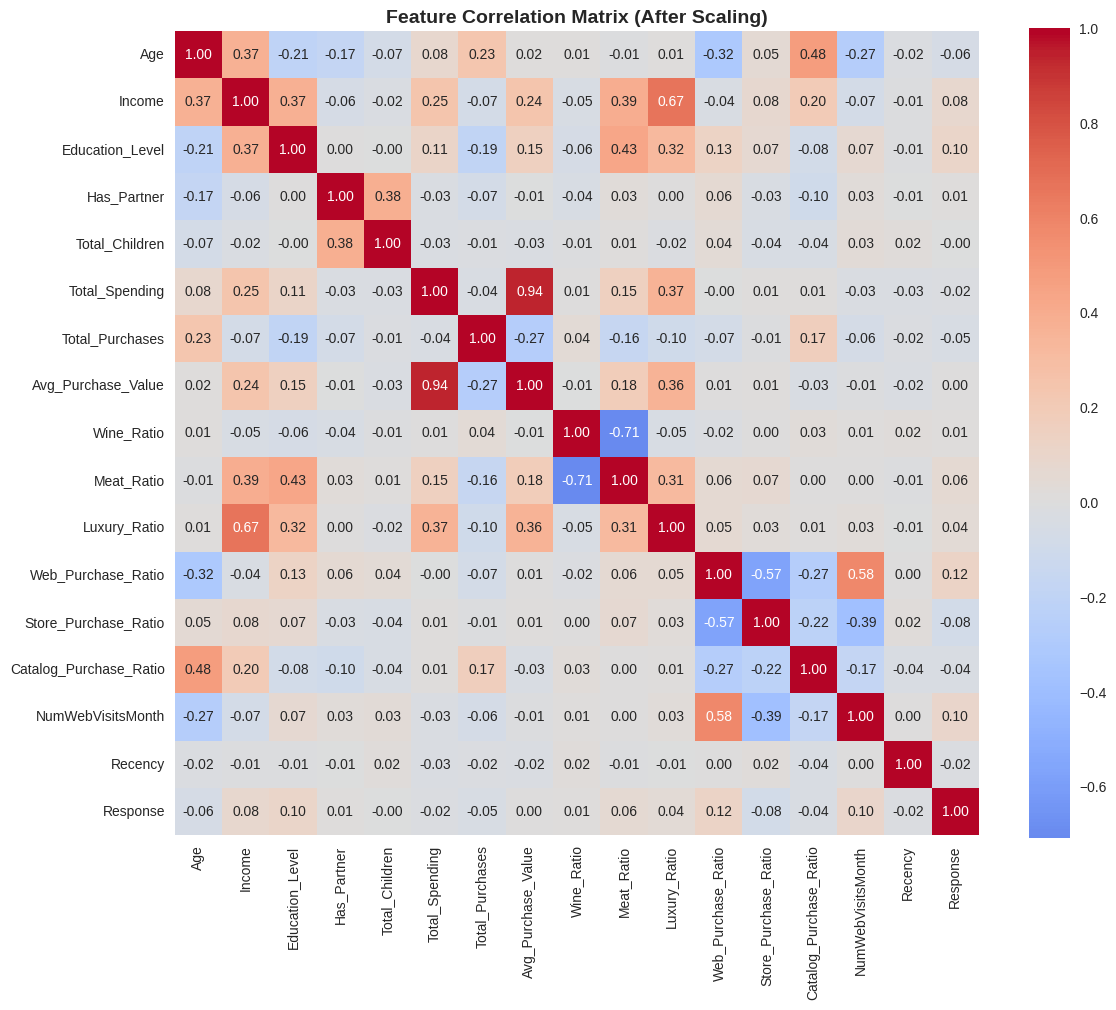


Correlation insights:
High correlation pairs (|r| > 0.5):
  Income - Luxury_Ratio: 0.671
  Total_Spending - Avg_Purchase_Value: 0.936
  Wine_Ratio - Meat_Ratio: -0.709
  Web_Purchase_Ratio - Store_Purchase_Ratio: -0.574
  Web_Purchase_Ratio - NumWebVisitsMonth: 0.583


In [22]:
# Step 3: Data Preprocessing
# Scale the features for clustering

print("=== DATA PREPROCESSING ===\n")

# Check feature distributions before scaling
print("Feature ranges before scaling:")
print(X.describe())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=final_features, index=X.index)

print("\nFeatures successfully standardized")
print("Feature ranges after scaling:")
print(X_scaled_df.describe())

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = X_scaled_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix (After Scaling)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation insights:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

if high_corr_pairs:
    print("High correlation pairs (|r| > 0.5):")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("No highly correlated features found (|r| > 0.5)")

=== DETERMINING OPTIMAL NUMBER OF CLUSTERS ===



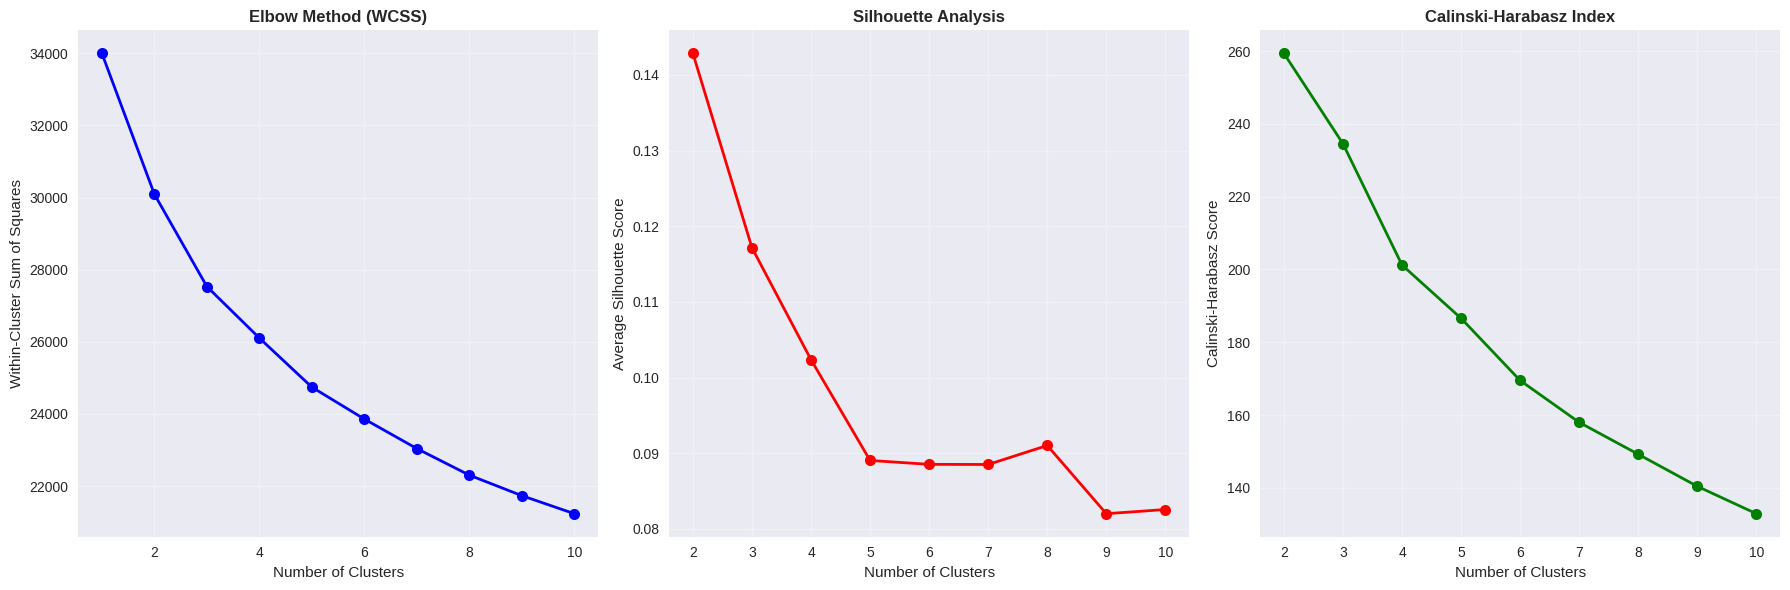

Cluster Analysis Results:
Best k by Silhouette Score: 2 (score: 0.143)
Best k by Calinski-Harabasz: 2 (score: 259.4)

Selected optimal number of clusters: 2


In [23]:
# Step 4: Determine Optimal Number of Clusters
# Use multiple methods to find the best number of clusters

print("=== DETERMINING OPTIMAL NUMBER OF CLUSTERS ===\n")

# Method 1: Elbow Method (Within-Cluster Sum of Squares)
def calculate_wcss(X, max_clusters=10):
    wcss = []
    k_range = range(1, max_clusters + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

    return k_range, wcss

# Method 2: Silhouette Analysis
def calculate_silhouette_scores(X, max_clusters=10):
    silhouette_scores = []
    k_range = range(2, max_clusters + 1)  # Silhouette score needs at least 2 clusters

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        silhouette_avg = silhouette_score(X, cluster_labels)
        silhouette_scores.append(silhouette_avg)

    return k_range, silhouette_scores

# Method 3: Calinski-Harabasz Index (Variance Ratio Criterion)
def calculate_calinski_harabasz_scores(X, max_clusters=10):
    ch_scores = []
    k_range = range(2, max_clusters + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        ch_score = calinski_harabasz_score(X, cluster_labels)
        ch_scores.append(ch_score)

    return k_range, ch_scores

# Calculate all metrics
max_k = 10
k_range_wcss, wcss_scores = calculate_wcss(X_scaled, max_k)
k_range_sil, silhouette_scores = calculate_silhouette_scores(X_scaled, max_k)
k_range_ch, ch_scores = calculate_calinski_harabasz_scores(X_scaled, max_k)

# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Elbow Method
axes[0].plot(k_range_wcss, wcss_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(k_range_sil, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz Index
axes[2].plot(k_range_ch, ch_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_title('Calinski-Harabasz Index', fontweight='bold')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of clusters
optimal_k_silhouette = k_range_sil[np.argmax(silhouette_scores)]
optimal_k_ch = k_range_ch[np.argmax(ch_scores)]

print("Cluster Analysis Results:")
print(f"Best k by Silhouette Score: {optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"Best k by Calinski-Harabasz: {optimal_k_ch} (score: {max(ch_scores):.1f})")

# Choose the final number of clusters (often a balance between metrics and interpretability)
optimal_k = optimal_k_silhouette
print(f"\nSelected optimal number of clusters: {optimal_k}")

In [25]:
# Step 5: Perform K-Means Clustering
# Create the customer personas using the optimal number of clusters

print("=== PERFORMING K-MEANS CLUSTERING ===\n")

# Use the optimal k determined in Step 4 and the preprocessed data from Step 3
print(f"Using optimal number of clusters: {optimal_k}")
print(f"Using {len(final_features)} features: {final_features}")

# Fit K-Means with the optimal number of clusters
final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=30,  # More initializations for better results
    max_iter=300
)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = cluster_labels

print(f"Clustering completed with {optimal_k} clusters")
print(f"Cluster distribution:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster_id}: {count:4d} customers ({percentage:5.1f}%)")

# Calculate final clustering metrics
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_ch_score = calinski_harabasz_score(X_scaled, cluster_labels)

print(f"\nFinal Clustering Quality Metrics:")
print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"Calinski-Harabasz Score: {final_ch_score:.1f}")

# Show cluster centers in terms of original features (for interpretability)
cluster_centers = final_kmeans.cluster_centers_
cluster_centers_df = pd.DataFrame(cluster_centers, columns=final_features)

print(f"\nCluster Centers (standardized values):")
print(cluster_centers_df.round(3))

=== PERFORMING K-MEANS CLUSTERING ===

Using optimal number of clusters: 2
Using 17 features: ['Age', 'Income', 'Education_Level', 'Has_Partner', 'Total_Children', 'Total_Spending', 'Total_Purchases', 'Avg_Purchase_Value', 'Wine_Ratio', 'Meat_Ratio', 'Luxury_Ratio', 'Web_Purchase_Ratio', 'Store_Purchase_Ratio', 'Catalog_Purchase_Ratio', 'NumWebVisitsMonth', 'Recency', 'Response']
Clustering completed with 2 clusters
Cluster distribution:
  Cluster 0:  652 customers ( 32.6%)
  Cluster 1: 1348 customers ( 67.4%)

Final Clustering Quality Metrics:
Silhouette Score: 0.142
Calinski-Harabasz Score: 259.4

Cluster Centers (standardized values):
    Age  Income  Education_Level  Has_Partner  Total_Children  Total_Spending  \
0 -0.04   0.808            0.701        0.042           0.021           0.745   
1  0.02  -0.391           -0.339       -0.020          -0.010          -0.360   

   Total_Purchases  Avg_Purchase_Value  Wine_Ratio  Meat_Ratio  Luxury_Ratio  \
0           -0.364            

In [26]:
# Step 6: Analyze and Interpret Clusters (Create Personas)
# Understand what each cluster represents

print("=== PERSONA ANALYSIS ===\n")

# First, let's check what columns we actually have
print("Available columns:", df.columns.tolist())
print("Cluster column exists:", 'Cluster' in df.columns)

# Let's also check the data types
print("\nData types:")
print(df.dtypes)

# If we don't have Education_Level, let's create it
if 'Education_Level' not in df.columns:
    education_mapping = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
    df['Education_Level'] = df['Education'].map(education_mapping)
    print("Created Education_Level column")

# If we don't have other derived columns, let's create them
if 'Has_Partner' not in df.columns:
    df['Has_Partner'] = df['Marital_Status'].isin(['Together', 'Married']).astype(int)
    print("Created Has_Partner column")

if 'Wine_Ratio' not in df.columns:
    df['Wine_Ratio'] = df['MntWines'] / (df['Total_Spending'] + 1)
    print("Created Wine_Ratio column")

if 'Meat_Ratio' not in df.columns:
    df['Meat_Ratio'] = df['MntMeatProducts'] / (df['Total_Spending'] + 1)
    print("Created Meat_Ratio column")

if 'Web_Purchase_Ratio' not in df.columns:
    df['Web_Purchase_Ratio'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1)
    print("Created Web_Purchase_Ratio column")

if 'Store_Purchase_Ratio' not in df.columns:
    df['Store_Purchase_Ratio'] = df['NumStorePurchases'] / (df['Total_Purchases'] + 1)
    print("Created Store_Purchase_Ratio column")

# Calculate cluster characteristics with only the columns we have
available_numeric_columns = {
    'Age': ['mean', 'std'],
    'Income': ['mean', 'std'],
    'Total_Spending': ['mean', 'std'],
    'Total_Purchases': ['mean', 'std'],
    'Total_Children': ['mean', 'std'],
    'Education_Level': 'mean',
    'Has_Partner': 'mean',
    'Wine_Ratio': 'mean',
    'Meat_Ratio': 'mean',
    'Web_Purchase_Ratio': 'mean',
    'Store_Purchase_Ratio': 'mean',
    'Recency': ['mean', 'std'],
    'NumWebVisitsMonth': ['mean', 'std'],
    'Response': 'mean'
}

# Filter to only include columns that actually exist in the dataframe
filtered_columns = {}
for col, agg_func in available_numeric_columns.items():
    if col in df.columns:
        filtered_columns[col] = agg_func
    else:
        print(f"Warning: Column '{col}' not found in dataframe")

cluster_profiles = df.groupby('Cluster').agg(filtered_columns).round(2)

print("Cluster Profiles (Statistical Summary):")
print(cluster_profiles)

=== PERSONA ANALYSIS ===

Available columns: ['ID', 'Year_Birth', 'Income', 'Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntMeatProducts', 'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Response', 'Age', 'Total_Spending', 'Total_Purchases', 'Total_Children', 'Education_Level', 'Has_Partner', 'Wine_Ratio', 'Meat_Ratio', 'Web_Purchase_Ratio', 'Store_Purchase_Ratio', 'Cluster', 'Luxury_Ratio', 'Catalog_Purchase_Ratio', 'Avg_Purchase_Value', 'Days_Since_Customer']
Cluster column exists: True

Data types:
ID                           int64
Year_Birth                   int64
Income                       int64
Education                 category
Marital_Status              object
Kidhome                      int64
Teenhome                     int64
Recency                      int64
MntWines                   float64
MntMeatProducts    

In [27]:
# Create detailed persona descriptions
def create_persona_descriptions(df, cluster_profiles):
    personas = {}

    for cluster_id in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster_id]

        # Basic demographics
        avg_age = cluster_profiles.loc[cluster_id, ('Age', 'mean')]
        avg_income = cluster_profiles.loc[cluster_id, ('Income', 'mean')]
        avg_spending = cluster_profiles.loc[cluster_id, ('Total_Spending', 'mean')]

        # Family characteristics
        avg_children = cluster_profiles.loc[cluster_id, ('Total_Children', 'mean')]
        partner_rate = cluster_profiles.loc[cluster_id, ('Has_Partner', 'mean')] * 100

        # Education
        avg_education = cluster_profiles.loc[cluster_id, ('Education_Level', 'mean')]
        education_levels = {1: 'Basic', 2: '2n Cycle', 3: 'Graduation', 4: 'Master', 5: 'PhD'}
        dominant_education = cluster_data['Education'].mode().iloc[0]

        # Shopping behavior
        avg_purchases = cluster_profiles.loc[cluster_id, ('Total_Purchases', 'mean')]
        web_ratio = cluster_profiles.loc[cluster_id, ('Web_Purchase_Ratio', 'mean')] * 100
        store_ratio = cluster_profiles.loc[cluster_id, ('Store_Purchase_Ratio', 'mean')] * 100
        wine_ratio = cluster_profiles.loc[cluster_id, ('Wine_Ratio', 'mean')] * 100

        # Engagement
        avg_recency = cluster_profiles.loc[cluster_id, ('Recency', 'mean')]
        avg_web_visits = cluster_profiles.loc[cluster_id, ('NumWebVisitsMonth', 'mean')]
        response_rate = cluster_profiles.loc[cluster_id, ('Response', 'mean')] * 100

        personas[cluster_id] = {
            'avg_age': avg_age,
            'avg_income': avg_income,
            'avg_spending': avg_spending,
            'avg_children': avg_children,
            'partner_rate': partner_rate,
            'dominant_education': dominant_education,
            'avg_purchases': avg_purchases,
            'web_ratio': web_ratio,
            'store_ratio': store_ratio,
            'wine_ratio': wine_ratio,
            'avg_recency': avg_recency,
            'avg_web_visits': avg_web_visits,
            'response_rate': response_rate,
            'size': len(cluster_data)
        }

    return personas

personas = create_persona_descriptions(df, cluster_profiles)

# Generate persona names and descriptions
persona_names = {}
persona_descriptions = {}

for cluster_id, stats in personas.items():
    # Determine persona characteristics for naming
    if stats['avg_spending'] > df['Total_Spending'].quantile(0.75):
        spending_level = "Premium"
    elif stats['avg_spending'] > df['Total_Spending'].quantile(0.25):
        spending_level = "Regular"
    else:
        spending_level = "Budget"

    if stats['avg_age'] < 35:
        age_group = "Young"
    elif stats['avg_age'] < 55:
        age_group = "Middle-aged"
    else:
        age_group = "Senior"

    if stats['web_ratio'] > 40:
        channel_pref = "Digital"
    else:
        channel_pref = "Traditional"

    # Create persona name
    persona_names[cluster_id] = f"{age_group} {spending_level} {channel_pref}"

    # Create detailed description
    description = f"""
PERSONA {cluster_id}: {persona_names[cluster_id]}
{'='*50}
Demographics:
• Average Age: {stats['avg_age']:.0f} years
• Average Income: ${stats['avg_income']:,.0f}
• Education: Primarily {stats['dominant_education']}
• Has Partner: {stats['partner_rate']:.0f}% have a partner
• Children at Home: {stats['avg_children']:.1f} on average

Spending Behavior:
• Total Annual Spending: ${stats['avg_spending']:,.0f}
• Wine Preference: {stats['wine_ratio']:.0f}% of spending on wine
• Purchase Frequency: {stats['avg_purchases']:.1f} purchases per period

Shopping Preferences:
• Web Purchases: {stats['web_ratio']:.0f}% of purchases online
• Store Purchases: {stats['store_ratio']:.0f}% of purchases in-store
• Website Visits: {stats['avg_web_visits']:.1f} visits per month

Engagement:
• Days Since Last Purchase: {stats['avg_recency']:.0f} days
• Campaign Response Rate: {stats['response_rate']:.1f}%
• Segment Size: {stats['size']:,} customers ({stats['size']/len(df)*100:.1f}% of total)
"""

    persona_descriptions[cluster_id] = description
    print(description)


PERSONA 0: Middle-aged Premium Traditional
Demographics:
• Average Age: 55 years
• Average Income: $103,630
• Education: Primarily PhD
• Has Partner: 46% have a partner
• Children at Home: 0.5 on average

Spending Behavior:
• Total Annual Spending: $777
• Wine Preference: 7% of spending on wine
• Purchase Frequency: 16.9 purchases per period

Shopping Preferences:
• Web Purchases: 15% of purchases online
• Store Purchases: 41% of purchases in-store
• Website Visits: 3.3 visits per month

Engagement:
• Days Since Last Purchase: 36 days
• Campaign Response Rate: 23.0%
• Segment Size: 652 customers (32.6% of total)


PERSONA 1: Senior Regular Traditional
Demographics:
• Average Age: 56 years
• Average Income: $79,961
• Education: Primarily Basic
• Has Partner: 43% have a partner
• Children at Home: 0.4 on average

Spending Behavior:
• Total Annual Spending: $286
• Wine Preference: 11% of spending on wine
• Purchase Frequency: 19.4 purchases per period

Shopping Preferences:
• Web Purchas

In [28]:
# Step 7: Visualize the Personas
# Create comprehensive visualizations to understand the clusters

print("=== PERSONA VISUALIZATIONS ===\n")

# Create a comprehensive dashboard
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=('Age Distribution by Cluster', 'Income Distribution by Cluster',
                   'Total Spending by Cluster', 'Education Level by Cluster',
                   'Shopping Channel Preferences', 'Product Category Preferences',
                   'Campaign Response Rates', 'Family Structure', 'Purchase Frequency'),
    specs=[[{"type": "box"}, {"type": "box"}, {"type": "box"}],
           [{"type": "bar"}, {"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}, {"type": "scatter"}]]
)

# Row 1: Box plots for continuous variables
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]

    # Age distribution
    fig.add_trace(go.Box(y=cluster_data['Age'], name=f'Cluster {cluster}',
                        legendgroup=f'cluster{cluster}', showlegend=False),
                 row=1, col=1)

    # Income distribution
    fig.add_trace(go.Box(y=cluster_data['Income'], name=f'Cluster {cluster}',
                        legendgroup=f'cluster{cluster}', showlegend=False),
                 row=1, col=2)

    # Spending distribution
    fig.add_trace(go.Box(y=cluster_data['Total_Spending'], name=f'Cluster {cluster}',
                        legendgroup=f'cluster{cluster}', showlegend=False),
                 row=1, col=3)

# Row 2: Bar charts for categorical data
# Education levels by cluster
education_by_cluster = df.groupby(['Cluster', 'Education']).size().unstack(fill_value=0)
for education in education_by_cluster.columns:
    fig.add_trace(go.Bar(x=education_by_cluster.index, y=education_by_cluster[education],
                        name=education, legendgroup='education'),
                 row=2, col=1)

# Shopping channels
channel_data = df.groupby('Cluster')[['Web_Purchase_Ratio', 'Store_Purchase_Ratio']].mean()
fig.add_trace(go.Bar(x=channel_data.index, y=channel_data['Web_Purchase_Ratio']*100,
                    name='Web Purchases', legendgroup='channels'),
             row=2, col=2)
fig.add_trace(go.Bar(x=channel_data.index, y=channel_data['Store_Purchase_Ratio']*100,
                    name='Store Purchases', legendgroup='channels'),
             row=2, col=2)

# Product preferences
product_data = df.groupby('Cluster')[['Wine_Ratio', 'Meat_Ratio']].mean()
fig.add_trace(go.Bar(x=product_data.index, y=product_data['Wine_Ratio']*100,
                    name='Wine %', legendgroup='products'),
             row=2, col=3)
fig.add_trace(go.Bar(x=product_data.index, y=product_data['Meat_Ratio']*100,
                    name='Meat %', legendgroup='products'),
             row=2, col=3)

# Row 3: Additional insights
# Response rates
response_by_cluster = df.groupby('Cluster')['Response'].mean() * 100
fig.add_trace(go.Bar(x=response_by_cluster.index, y=response_by_cluster.values,
                    name='Response Rate %', legendgroup='response', showlegend=False),
             row=3, col=1)

# Family structure
family_data = df.groupby('Cluster')[['Has_Partner', 'Total_Children']].mean()
fig.add_trace(go.Bar(x=family_data.index, y=family_data['Has_Partner']*100,
                    name='Has Partner %', legendgroup='family'),
             row=3, col=2)
fig.add_trace(go.Bar(x=family_data.index, y=family_data['Total_Children'],
                    name='Avg Children', legendgroup='family', yaxis='y2'),
             row=3, col=2)

# Purchase frequency vs spending
cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
for i, cluster in enumerate(sorted(df['Cluster'].unique())):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(x=cluster_data['Total_Purchases'], y=cluster_data['Total_Spending'],
                           mode='markers', name=f'Cluster {cluster}',
                           marker=dict(color=cluster_colors[i % len(cluster_colors)]),
                           legendgroup=f'scatter_cluster{cluster}'),
                 row=3, col=3)

fig.update_layout(height=1200, title_text="Customer Personas - Comprehensive Analysis",
                 title_x=0.5, title_font_size=16)
fig.show()

=== PERSONA VISUALIZATIONS ===



In [29]:
# Step 8: Validate the Clustering Results
# Ensure our personas are meaningful and stable

print("=== CLUSTERING VALIDATION ===\n")

# Validation 1: Stability Analysis (Bootstrap sampling)
def stability_analysis(X, n_clusters, n_iterations=100):
    """Measure clustering stability using bootstrap sampling"""
    from sklearn.metrics import adjusted_rand_score

    stability_scores = []
    original_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    original_labels = original_kmeans.fit_predict(X)

    for i in range(n_iterations):
        # Bootstrap sample
        sample_indices = np.random.choice(len(X), size=len(X), replace=True)
        X_bootstrap = X[sample_indices]

        # Fit clustering on bootstrap sample
        bootstrap_kmeans = KMeans(n_clusters=n_clusters, random_state=i, n_init=10)
        bootstrap_labels = bootstrap_kmeans.fit_predict(X_bootstrap)

        # Create full labels for comparison
        full_bootstrap_labels = np.full(len(X), -1)
        full_bootstrap_labels[sample_indices] = bootstrap_labels

        # Calculate stability (only for sampled points)
        sampled_original = original_labels[sample_indices]
        stability_score = adjusted_rand_score(sampled_original, bootstrap_labels)
        stability_scores.append(stability_score)

    return np.mean(stability_scores), np.std(stability_scores)

stability_mean, stability_std = stability_analysis(X_scaled, optimal_k)
print(f"Clustering Stability Analysis:")
print(f"  Mean ARI Score: {stability_mean:.3f} ± {stability_std:.3f}")
print(f"  Interpretation: {'Stable' if stability_mean > 0.7 else 'Moderately Stable' if stability_mean > 0.5 else 'Unstable'}")

# Validation 2: Feature Importance for Cluster Discrimination
# Train a classifier to predict clusters and see which features are most important
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_scaled, cluster_labels)

feature_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importance for Cluster Discrimination:")
print("(How well each feature distinguishes between clusters)")
for i, row in feature_importance.iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.3f}")

# Validation 3: Cluster Separation Analysis
print(f"\nCluster Separation Analysis:")
print(f"  Silhouette Score: {final_silhouette:.3f}")
if final_silhouette > 0.5:
    separation_quality = "Good"
elif final_silhouette > 0.3:
    separation_quality = "Moderate"
else:
    separation_quality = "Poor"
print(f"  Separation Quality: {separation_quality}")

# Validation 4: Business Relevance Check
print(f"\nBusiness Relevance Validation:")
print("Checking if clusters show meaningful differences in key business metrics...")

business_metrics = ['Total_Spending', 'Total_Purchases', 'Response', 'Income']
for metric in business_metrics:
    cluster_means = df.groupby('Cluster')[metric].mean()
    coefficient_of_variation = cluster_means.std() / cluster_means.mean()
    print(f"  {metric:15s}: CV = {coefficient_of_variation:.3f} {'(Good variation)' if coefficient_of_variation > 0.2 else '(Low variation)'}")

=== CLUSTERING VALIDATION ===

Clustering Stability Analysis:
  Mean ARI Score: 0.888 ± 0.065
  Interpretation: Stable

Feature Importance for Cluster Discrimination:
(How well each feature distinguishes between clusters)
  Luxury_Ratio        : 0.242
  Avg_Purchase_Value  : 0.146
  Meat_Ratio          : 0.143
  Income              : 0.138
  Total_Spending      : 0.095
  Education_Level     : 0.080
  Total_Purchases     : 0.030
  Wine_Ratio          : 0.029
  Age                 : 0.019
  Web_Purchase_Ratio  : 0.018
  Store_Purchase_Ratio: 0.014
  Recency             : 0.013
  Catalog_Purchase_Ratio: 0.013
  NumWebVisitsMonth   : 0.011
  Total_Children      : 0.004
  Has_Partner         : 0.002
  Response            : 0.002

Cluster Separation Analysis:
  Silhouette Score: 0.142
  Separation Quality: Poor

Business Relevance Validation:
Checking if clusters show meaningful differences in key business metrics...
  Total_Spending : CV = 0.654 (Good variation)
  Total_Purchases: CV = 0.09

=== CLUSTER VISUALIZATION WITH PCA ===



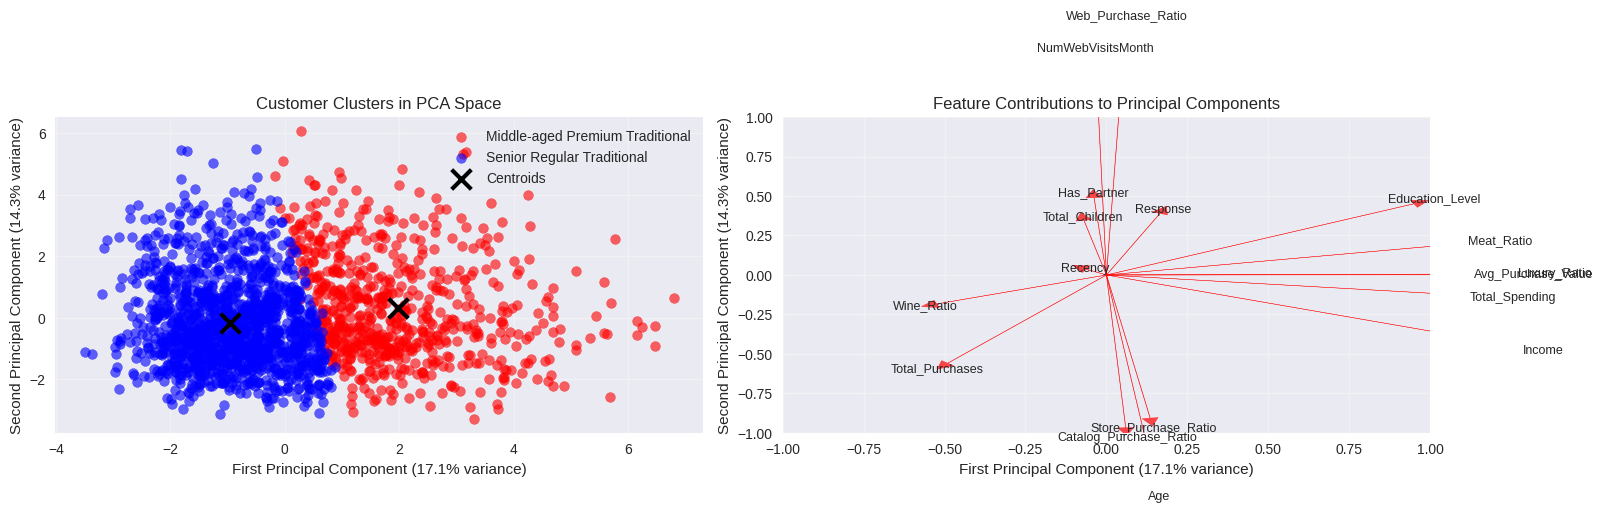

PCA Explained Variance:
  PC1: 17.1%
  PC2: 14.3%
  Total: 31.5%


In [30]:
# Step 9: Principal Component Analysis for Visualization
# Create a 2D visualization of the clusters

print("=== CLUSTER VISUALIZATION WITH PCA ===\n")

# Perform PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a comprehensive PCA plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters in PCA space
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = X_pca[df['Cluster'] == cluster_id]
    axes[0].scatter(cluster_data[:, 0], cluster_data[:, 1],
                   c=colors[cluster_id % len(colors)],
                   label=f'{persona_names[cluster_id]}',
                   alpha=0.6, s=50)

# Add cluster centers
cluster_centers_pca = pca.transform(final_kmeans.cluster_centers_)
axes[0].scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1],
               c='black', marker='x', s=200, linewidths=3, label='Centroids')

axes[0].set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Customer Clusters in PCA Space')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature contributions to PCA components
feature_weights = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=final_features
)

# Create a biplot-style visualization
for i, feature in enumerate(final_features):
    axes[1].arrow(0, 0, feature_weights.loc[feature, 'PC1']*3, feature_weights.loc[feature, 'PC2']*3,
                 head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.7)
    axes[1].text(feature_weights.loc[feature, 'PC1']*3.2, feature_weights.loc[feature, 'PC2']*3.2,
                feature, fontsize=9, ha='center', va='center')

axes[1].set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Feature Contributions to Principal Components')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

print(f"PCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.1%}")

In [31]:
# Step 10: Generate Actionable Insights and Recommendations
# Provide business recommendations for each persona

print("=== ACTIONABLE BUSINESS INSIGHTS ===\n")

def generate_recommendations(cluster_id, stats, persona_name):
    recommendations = []

    # Spending-based recommendations
    if stats['avg_spending'] > df['Total_Spending'].quantile(0.75):
        recommendations.append("🎯 High-value segment - Focus on premium products and exclusive offers")
        recommendations.append("💎 Implement VIP loyalty program with personalized services")
    elif stats['avg_spending'] < df['Total_Spending'].quantile(0.25):
        recommendations.append("💰 Price-sensitive segment - Emphasize value propositions and discounts")
        recommendations.append("🏷️ Promote bundle deals and seasonal sales")

    # Channel-based recommendations
    if stats['web_ratio'] > 50:
        recommendations.append("🌐 Digital-first approach - Invest in online experience and mobile app")
        recommendations.append("📱 Leverage social media marketing and email campaigns")
    else:
        recommendations.append("🏪 Traditional retail focus - Enhance in-store experience")
        recommendations.append("📰 Use traditional marketing channels (print, direct mail)")

    # Age-based recommendations
    if stats['avg_age'] < 35:
        recommendations.append("🎮 Target with trendy, innovative products")
        recommendations.append("📸 Use visual social media platforms (Instagram, TikTok)")
    elif stats['avg_age'] > 55:
        recommendations.append("🎯 Focus on quality, reliability, and customer service")
        recommendations.append("📞 Provide multiple customer support channels")

    # Family-based recommendations
    if stats['avg_children'] > 0.5:
        recommendations.append("👨‍👩‍👧‍👦 Family-oriented marketing and bulk purchasing options")
        recommendations.append("🎈 Promote family-friendly products and experiences")

    # Engagement-based recommendations
    if stats['response_rate'] > 20:
        recommendations.append("📧 Highly responsive - Increase campaign frequency")
        recommendations.append("🎯 A/B test new campaign types with this engaged segment")
    elif stats['response_rate'] < 10:
        recommendations.append("🔄 Low engagement - Re-activation campaigns needed")
        recommendations.append("💡 Experiment with different messaging and incentives")

    return recommendations

print("PERSONA-SPECIFIC MARKETING STRATEGIES")
print("="*60)

for cluster_id in sorted(personas.keys()):
    stats = personas[cluster_id]
    persona_name = persona_names[cluster_id]

    print(f"\n🎭 PERSONA {cluster_id}: {persona_name}")
    print(f"📊 Size: {stats['size']:,} customers ({stats['size']/len(df)*100:.1f}% of total)")
    print(f"💰 Revenue Potential: ${stats['avg_spending'] * stats['size']:,.0f} annually")

    recommendations = generate_recommendations(cluster_id, stats, persona_name)
    print("📝 Recommendations:")
    for rec in recommendations:
        print(f"   {rec}")

    print("-" * 60)

# Overall portfolio insights
print(f"\n🔍 PORTFOLIO INSIGHTS:")
print(f"📈 Total Annual Revenue: ${df['Total_Spending'].sum():,.0f}")
print(f"👥 Total Customers: {len(df):,}")
print(f"💵 Average Customer Value: ${df['Total_Spending'].mean():,.0f}")

# Identify the most valuable segments
segment_values = []
for cluster_id in sorted(personas.keys()):
    stats = personas[cluster_id]
    total_value = stats['avg_spending'] * stats['size']
    segment_values.append((cluster_id, persona_names[cluster_id], total_value, stats['size']))

segment_values.sort(key=lambda x: x[2], reverse=True)

print(f"\n🏆 SEGMENT RANKING BY TOTAL VALUE:")
for i, (cluster_id, name, value, size) in enumerate(segment_values, 1):
    percentage = (value / df['Total_Spending'].sum()) * 100
    print(f"  {i}. {name}: ${value:,.0f} ({percentage:.1f}% of total revenue)")

=== ACTIONABLE BUSINESS INSIGHTS ===

PERSONA-SPECIFIC MARKETING STRATEGIES

🎭 PERSONA 0: Middle-aged Premium Traditional
📊 Size: 652 customers (32.6% of total)
💰 Revenue Potential: $506,871 annually
📝 Recommendations:
   🎯 High-value segment - Focus on premium products and exclusive offers
   💎 Implement VIP loyalty program with personalized services
   🏪 Traditional retail focus - Enhance in-store experience
   📰 Use traditional marketing channels (print, direct mail)
   📧 Highly responsive - Increase campaign frequency
   🎯 A/B test new campaign types with this engaged segment
------------------------------------------------------------

🎭 PERSONA 1: Senior Regular Traditional
📊 Size: 1,348 customers (67.4% of total)
💰 Revenue Potential: $385,043 annually
📝 Recommendations:
   🏪 Traditional retail focus - Enhance in-store experience
   📰 Use traditional marketing channels (print, direct mail)
   🎯 Focus on quality, reliability, and customer service
   📞 Provide multiple customer sup

In [32]:
# Step 11: Export Results and Create Summary Report
# Generate a comprehensive summary for stakeholders

print("=== EXECUTIVE SUMMARY ===\n")

summary_report = f"""
CUSTOMER PERSONA ANALYSIS - EXECUTIVE SUMMARY
{'='*60}

METHODOLOGY:
• Analyzed {len(df):,} customers using K-Means clustering
• Used {len(final_features)} key features including demographics, spending, and behavior
• Identified {optimal_k} distinct customer personas
• Validated clustering with multiple metrics (Silhouette Score: {final_silhouette:.3f})

KEY FINDINGS:
"""

# Add key findings for each persona
for i, (cluster_id, name, value, size) in enumerate(segment_values, 1):
    stats = personas[cluster_id]
    summary_report += f"""
{i}. {name} ({size:,} customers, {size/len(df)*100:.1f}%):
   • Average Spending: ${stats['avg_spending']:,.0f}
   • Total Revenue: ${value:,.0f} ({value/df['Total_Spending'].sum()*100:.1f}% of total)
   • Key Characteristics: Age {stats['avg_age']:.0f}, Income ${stats['avg_income']:,.0f}
   • Response Rate: {stats['response_rate']:.1f}%
"""

summary_report += f"""
STRATEGIC RECOMMENDATIONS:
1. Prioritize top revenue-generating segments for immediate ROI
2. Develop segment-specific marketing campaigns and messaging
3. Optimize channel mix based on persona preferences
4. Implement targeted retention strategies for high-value customers
5. Create acquisition strategies to attract similar high-value prospects

NEXT STEPS:
• Implement persona-based marketing campaigns
• Monitor segment performance and evolution over time
• Conduct A/B testing on persona-specific strategies
• Regular re-clustering to identify emerging patterns
"""

print(summary_report)

# Create a simple export of cluster assignments for business use
cluster_export = df[['ID', 'Cluster'] + final_features].copy()
cluster_export['Persona_Name'] = cluster_export['Cluster'].map(persona_names)

print(f"\n✅ ANALYSIS COMPLETE!")
print(f"📊 Created {optimal_k} customer personas from {len(df):,} customers")
print(f"🎯 Each customer now has a cluster assignment and persona name")
print(f"📈 Ready for implementation in marketing campaigns and strategy")

# Display first few rows of the final dataset
print(f"\nSample of final dataset with persona assignments:")
print(cluster_export.head(10))

=== EXECUTIVE SUMMARY ===


CUSTOMER PERSONA ANALYSIS - EXECUTIVE SUMMARY

METHODOLOGY:
• Analyzed 2,000 customers using K-Means clustering
• Used 17 key features including demographics, spending, and behavior
• Identified 2 distinct customer personas
• Validated clustering with multiple metrics (Silhouette Score: 0.142)

KEY FINDINGS:

1. Middle-aged Premium Traditional (652 customers, 32.6%):
   • Average Spending: $777
   • Total Revenue: $506,871 (56.8% of total)
   • Key Characteristics: Age 55, Income $103,630
   • Response Rate: 23.0%

2. Senior Regular Traditional (1,348 customers, 67.4%):
   • Average Spending: $286
   • Total Revenue: $385,043 (43.2% of total)
   • Key Characteristics: Age 56, Income $79,961
   • Response Rate: 18.0%

STRATEGIC RECOMMENDATIONS:
1. Prioritize top revenue-generating segments for immediate ROI
2. Develop segment-specific marketing campaigns and messaging
3. Optimize channel mix based on persona preferences
4. Implement targeted retention strateg